In [1]:
import os
import sys

sys.path.append(os.getcwd())

In [2]:
from src.data.build_dataset import build_market_dataset

df = build_market_dataset()
df.head()

,date,SPY,QQQ,DIA,IWN
0,2002-01-03,1.127519,3.406775,0.975425,1.156449
1,2002-01-04,0.665375,0.408802,0.857495,0.847332
2,2002-01-07,-0.708118,-1.110050,-0.612907,-1.100651
3,2002-01-08,-0.231511,0.677149,-0.457057,0.803877
4,2002-01-09,-0.818595,-0.920103,-0.557779,-0.389629


In [3]:
df.shape

(6021, 5)

In [4]:
df.describe()

,date,SPY,QQQ,DIA,IWN
count,6021,6021.000000,6021.000000,6021.000000,6021.000000
mean,2014-01-16 08:07:24.843049472,0.039695,0.047040,0.026213,0.033360
min,2002-01-03 00:00:00,-11.588661,-12.759215,-13.841813,-14.064349
25%,2008-01-03 00:00:00,-0.422976,-0.591504,-0.436183,-0.686882
50%,2013-12-24 00:00:00,0.071503,0.114323,0.053446,0.068304
75%,2020-02-24 00:00:00,0.587825,0.760659,0.549566,0.809751
max,2026-02-19 00:00:00,19.985740,11.479906,10.764325,9.062167
std,NaN,1.230961,1.438580,1.146539,1.518730


<Axes: >

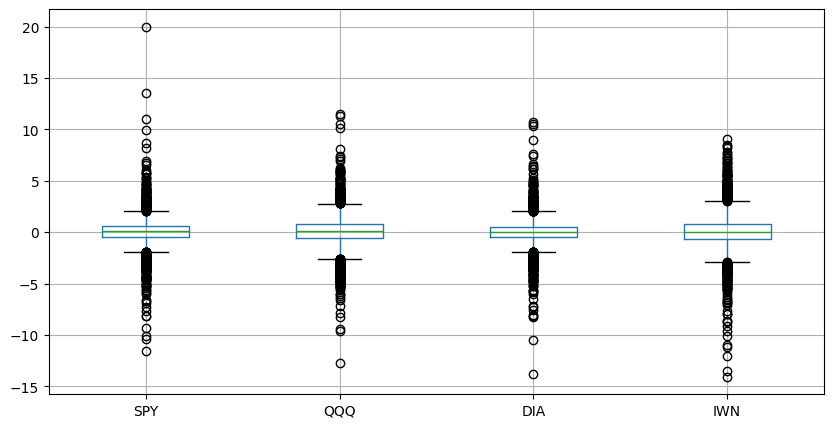

In [5]:
df.boxplot(figsize=(10,5))

we can see many assymetric tails and outliers beyond whiskers, which is our motivation to do flexible innovations

# Base VAR Test

In [6]:
from src.models.base_var import BaseVAR

var = BaseVAR(p=2, intercept=True)
design = var.build_design(df)

print("X shape:", design.X.shape)
print("Y shape:", design.Y.shape)
print("Dates shape:", design.dates.shape)
print("First 10 feature names:", design.feature_names[:10])

X shape: (6019, 9)
Y shape: (6019, 4)
Dates shape: (6019,)
First 10 feature names: ['intercept', 'SPY_lag1', 'QQQ_lag1', 'DIA_lag1', 'IWN_lag1', 'SPY_lag2', 'QQQ_lag2', 'DIA_lag2', 'IWN_lag2']


# Gaussian VAR w/ OLS

In [7]:
from src.models.gaussian_var import GaussianVAR

model = GaussianVAR(p=2, intercept=True)
result = model.fit(df)

model.summary()

/Users/jonathanma/Desktop/MSEnotes/724_ProbML/Final Project/pml-project-MaZhuTao-SP26/src/models/gaussian_var.py:78: RuntimeWarning: divide by zero encountered in matmul
  XtX = X.T @ X
/Users/jonathanma/Desktop/MSEnotes/724_ProbML/Final Project/pml-project-MaZhuTao-SP26/src/models/gaussian_var.py:78: RuntimeWarning: overflow encountered in matmul
  XtX = X.T @ X
/Users/jonathanma/Desktop/MSEnotes/724_ProbML/Final Project/pml-project-MaZhuTao-SP26/src/models/gaussian_var.py:78: RuntimeWarning: invalid value encountered in matmul
  XtX = X.T @ X
/Users/jonathanma/Desktop/MSEnotes/724_ProbML/Final Project/pml-project-MaZhuTao-SP26/src/models/gaussian_var.py:79: RuntimeWarning: divide by zero encountered in matmul
  XtY = X.T @ Y
/Users/jonathanma/Desktop/MSEnotes/724_ProbML/Final Project/pml-project-MaZhuTao-SP26/src/models/gaussian_var.py:79: RuntimeWarning: overflow encountered in matmul
  XtY = X.T @ Y
/Users/jonathanma/Desktop/MSEnotes/724_ProbML/Final Project/pml-project-MaZhuTao-SP

{'p': 2,
 'intercept': True,
 'n_obs_effective': 6019,
 'n_series': 4,
 'n_features': 9,
 'beta_shape': (4, 9),
 'sigma_shape': (4, 4)}